# Intergrated Gradiance analysis on encoder

## 1. Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from captum.attr import IntegratedGradients

# Set matplotlib to inline mode for Jupyter notebook display
%matplotlib inline

# Configure seaborn style for better looking plots
sns.set_style("whitegrid")

## 2. Define the used functions

In [2]:
class ViTChannelIGAnalyzer:
    """
    Integrated Gradients analyzer for ViT encoder to compare RGB vs Depth channel importance
    """
    
    def __init__(self, model, n_steps=30):
        """
        Initialize the IG analyzer
        
        Parameters:
        ----------
        model : torch.nn.Module
            The ViT encoder model with .encode() method
        n_steps : int
            Number of steps for Integrated Gradients approximation
        """
        self.model = model
        self.n_steps = n_steps
        self.ig = IntegratedGradients(self._forward_wrapper)
        
    def _forward_wrapper(self, pixels, extra_inputs=None):
        """Wrapper function for Integrated Gradients.

        Parameters:
        ----------
        pixels : torch.Tensor
            The image tensor to compute attributions for.
        extra_inputs : dict, optional
            Other keys from the batch (e.g. action, observation, etc.)
        """

        inputs = {}
        if extra_inputs is not None:
            inputs.update(extra_inputs)

        inputs["pixels"] = pixels

        output = self.model.encode(inputs)
        scalar_energy = torch.sum(output["emb"] ** 2).view(1)
        
        return scalar_energy
    
    def compute_channel_attributions(self, batch, target_channels=None):
        """
        Compute Integrated Gradients attributions for each channel
        
        Parameters:
        ----------
        batch : dict
            Input dict including 'Pixels' of shape (batch, channels, height, width)
            where channels = 4 (RGB + Depth)
        target_channels : list, optional
            List of channel indices to analyze (default: all 4 channels)
            
        Returns:
        -------
        dict
            Dictionary containing attributions for each channel
        """
        if target_channels is None:
            target_channels = [0, 1, 2, 3]  # All channels
        
        inputs = {k: v for k, v in batch.items()}
        if isinstance(inputs["pixels"], torch.Tensor):
            pixels = inputs["pixels"].clone().detach().requires_grad_(True)
        else:
            pixels = torch.tensor(inputs["pixels"], dtype=torch.float32).requires_grad_(True)

        inputs["pixels"] = pixels
        
        with torch.enable_grad():
            # Create baseline (zeros with same shape as input)
            pixels = batch["pixels"]
            baseline = torch.zeros_like(pixels)

            extra_inputs = {k: v for k, v in batch.items() if k != "pixels"}
            
            # Compute attributions for the entire input
            attributions = self.ig.attribute(
                inputs=pixels,
                baselines=baseline,
                additional_forward_args=(extra_inputs,),
                n_steps=self.n_steps,
                internal_batch_size=2,
                target=None  # Use default output
            )

            # Aggregate over the sequence dimension (dimension 1)
            # Sum over the extra dimension to get (batch, channels, height, width)
            attributions_agg = attributions.sum(dim=1)  # Shape: (batch, 4, height, width)
            print(attributions_agg.shape) # FIXME print shows torch.Size([1, 4, 224, 224])
            
            # attributions shape: (batch, channels, height, width)
            # Aggregate over spatial dimensions and batch
            channel_attributions = {}
            channel_importance = {}
            
            for ch_idx in target_channels:
                # Get attributions for this channel
                ch_attr = attributions_agg[:, ch_idx, :, :]  # (batch, h, w)
                print("ch_attr has shape",ch_attr.shape) # FIXME print shows torch.Size([1, 224, 224])
                
                # Compute importance as sum of absolute values
                # Average over batch, sum over spatial
                importance = torch.abs(ch_attr).sum(dim=(1, 2)).mean().item()
                
                channel_attributions[f'channel_{ch_idx}'] = ch_attr.mean(dim=0).detach().cpu().numpy()
                channel_importance[f'channel_{ch_idx}'] = importance
            
            # Separate RGB and Depth
            rgb_importance = sum([channel_importance[f'channel_{i}'] for i in range(3)])
            depth_importance = channel_importance.get('channel_3', 0)
            total_importance = rgb_importance + depth_importance
            
            return {
                'attributions': channel_attributions,
                'importance': channel_importance,
                'rgb_importance': rgb_importance,
                'depth_importance': depth_importance,
                'total_importance': total_importance,
                'rgb_percentage': (rgb_importance / total_importance * 100) if total_importance > 0 else 0,
                'depth_percentage': (depth_importance / total_importance * 100) if total_importance > 0 else 0
            }
    
    def visualize_attributions(self, results, save_path=None):
        """
        Visualize the attribution results
        
        Parameters:
        ----------
        results : dict
            Results from compute_channel_attributions()
        save_path : str, optional
            Path to save the figure
        """
        fig, axes = plt.subplots(1, 1, figsize=(15, 10))
        fig.suptitle('Integrated Gradients Attributions by Channel', fontsize=14, fontweight='bold')
        
        channel_names = ['RGB1', 'RGB2', 'RGB3', 'Depth']
        colors = ["#FF0000", '#00FF00', '#0000FF', '#FFFF00']
        
        # Plot importance bar chart
        # ax = axes[0, 0]
        ax = axes
        importances = [
            results['importance'].get('channel_0', 0),
            results['importance'].get('channel_1', 0),
            results['importance'].get('channel_2', 0),
            results['importance'].get('channel_3', 0)
        ]
        bars = ax.bar(channel_names, importances, color=colors)
        ax.set_title('Channel Importance (Integrated Gradients)')
        ax.set_ylabel('Attribution Magnitude')
        ax.grid(True, alpha=0.3)
        
        # Add percentage labels on bars
        total = sum(importances)
        for bar, val in zip(bars, importances):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val/total*100:.1f}%',
                    ha='center', va='bottom')
        
        # # Plot RGB vs Depth pie chart
        # ax = axes[0, 1]
        # rgb_total = sum([results['importance'].get(f'channel_{i}', 0) for i in range(3)])
        # depth_total = results['importance'].get('channel_3', 0)
        # sizes = [rgb_total, depth_total]
        # labels = ['RGB (3 channels)', 'Depth (1 channel)']
        # colors_pie = ['#457B9D', '#F4A261']
        # ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
        # ax.set_title('RGB vs Depth Contribution')
        
        # # Plot RGB vs Depth bar comparison
        # ax = axes[0, 2]
        # ax.bar(['RGB (total)', 'Depth'], [rgb_total, depth_total], color=['#457B9D', '#F4A261'])
        # ax.set_title('RGB vs Depth Total Importance')
        # ax.set_ylabel('Attribution Magnitude')
        # ax.grid(True, alpha=0.3)
        
        # # Plot attributions heatmaps for each channel
        # for i in range(4):
        #     if i < 3:
        #         ax = axes[1, i]
        #     else:
        #         ax = axes[2, 1]  # Depth goes to the last position
            
        #     # Get attributions for this channel (take first sample)
        #     attr_key = f'channel_{i}'
        #     if attr_key in results['attributions']:
        #         attr_data = results['attributions'][attr_key]
                
        #         # Normalize for visualization
        #         max_abs = max(abs(attr_data.min()), abs(attr_data.max()))
        #         if max_abs > 1e-8:
        #             attr_data = attr_data / max_abs
                    
        #         im = ax.imshow(attr_data, cmap='RdBu', interpolation='bilinear')
        #         ax.set_title(f'Channel {i+1} Attributions')
        #         ax.axis('off')
        #         plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        plt.show()
    
    def print_summary(self, results):
        """
        Print a summary of the attribution results
        
        Parameters:
        ----------
        results : dict
            Results from compute_channel_attributions()
        """
        print("=" * 60)
        print("INTEGRATED GRADIENTS CHANNEL IMPORTANCE SUMMARY")
        print("=" * 60)
        
        # Per-channel importance
        print("\n--- Per-Channel Importance ---")
        total = results['total_importance']
        for i in range(4):
            key = f'channel_{i}'
            if key in results['importance']:
                val = results['importance'][key]
                pct = (val / total * 100) if total > 0 else 0
                channel_type = 'Depth' if i == 3 else f'RGB{i+1}'
                print(f"{channel_type}: {val:.6f} ({pct:.1f}%)")
        
        # RGB vs Depth summary
        print("\n--- RGB vs Depth ---")
        print(f"RGB Total (3 channels): {results['rgb_importance']:.6f} ({results['rgb_percentage']:.1f}%)")
        print(f"Depth Total (1 channel): {results['depth_importance']:.6f} ({results['depth_percentage']:.1f}%)")
        
        # Diagnosis
        print("\n--- Diagnosis ---")
        if results['depth_percentage'] > 50:
            print("🚨 CRITICAL: Depth channel dominates the attributions!")
            print(f"   Depth contributes {results['depth_percentage']:.1f}% vs RGB {results['rgb_percentage']:.1f}%")
            print("   → This suggests the model is heavily relying on depth information")
        elif results['depth_percentage'] > 35:
            print("⚠️  WARNING: Depth channel has significant influence")
            print(f"   Depth contributes {results['depth_percentage']:.1f}% vs RGB {results['rgb_percentage']:.1f}%")
        else:
            print("✅ Channel contributions are relatively balanced")
            print(f"   Depth: {results['depth_percentage']:.1f}%, RGB: {results['rgb_percentage']:.1f}%")
        
        # Comparison with previous weight analysis
        print("\n--- Comparison with Weight Analysis ---")
        print("Weight analysis showed: Depth 54.7%, RGB 45.3%")
        print(f"IG analysis shows: Depth {results['depth_percentage']:.1f}%, RGB {results['rgb_percentage']:.1f}%")
        
        if abs(results['depth_percentage'] - 54.7) > 10:
            print("⚠️  Significant difference between weight and attribution analysis!")
            print("   → This indicates the model's behavior may not match its weight distribution")
        else:
            print("✅ IG analysis confirms the weight distribution findings")
        
        print("=" * 60)
        
        return {
            'depth_percentage': results['depth_percentage'],
            'rgb_percentage': results['rgb_percentage'],
            'weight_depth': 54.7,
            'weight_rgb': 45.3,
            'agreement': abs(results['depth_percentage'] - 54.7) < 10
        }

In [3]:
def analyze_model_channels(model, batch, n_steps=30, visualize=True):
    """
    Convenience function to run complete channel attribution analysis
    
    Parameters:
    ----------
    model : torch.nn.Module
        ViT encoder model with .encode() method
    batch : torch.Tensor
        Input batch of shape (batch, 4, height, width)
    n_steps : int
        Number of IG steps
    visualize : bool
        Whether to plot visualizations
    
    Returns:
    -------
    dict
        Analysis results
    """
    analyzer = ViTChannelIGAnalyzer(model, n_steps=n_steps)
    
    # Compute attributions
    results = analyzer.compute_channel_attributions(batch)
    
    # Print summary
    analyzer.print_summary(results)
    
    # Visualize
    if visualize:
        analyzer.visualize_attributions(results)
    
    return results


# For batched analysis across multiple samples:
def analyze_batch_samples(model, batch_data, ctx_len=1, n_steps=50):
    """
    Analyze channel importance across multiple samples
    
    Parameters:
    ----------
    model : torch.nn.Module
        The model
    batch_data : torch.Tensor
        Batch of inputs (batch, 4, h, w)
    ctx_len : int
        Context length
    n_steps : int
        Number of IG steps
    
    Returns:
    -------
    dict
        Aggregate statistics across samples
    """
    analyzer = ViTChannelIGAnalyzer(model, ctx_len=ctx_len, n_steps=n_steps)
    
    all_results = []
    
    for i in range(batch_data.shape[0]):
        single_batch = batch_data[i:i+1]  # Shape: (1, 4, h, w)
        results = analyzer.compute_channel_attributions(single_batch)
        all_results.append({
            'depth_pct': results['depth_percentage'],
            'rgb_pct': results['rgb_percentage'],
            'depth_importance': results['depth_importance'],
            'rgb_importance': results['rgb_importance']
        })
    
    # Aggregate
    depth_pcts = [r['depth_pct'] for r in all_results]
    rgb_pcts = [r['rgb_pct'] for r in all_results]
    
    print("=" * 60)
    print("BATCH AGGREGATE ANALYSIS")
    print("=" * 60)
    print(f"Average Depth contribution: {np.mean(depth_pcts):.1f}% ± {np.std(depth_pcts):.1f}%")
    print(f"Average RGB contribution: {np.mean(rgb_pcts):.1f}% ± {np.std(rgb_pcts):.1f}%")
    print(f"Sample variance: {np.var(depth_pcts):.2f}")
    
    if np.std(depth_pcts) > 10:
        print("⚠️  High variance across samples - model behavior is inconsistent")
    else:
        print("✅ Consistent behavior across samples")
    
    return {
        'depth_mean': np.mean(depth_pcts),
        'depth_std': np.std(depth_pcts),
        'rgb_mean': np.mean(rgb_pcts),
        'rgb_std': np.std(rgb_pcts),
        'per_sample': all_results
    }

## 3. Set the Path

In [4]:
CKPT_PATH = "/home/student/users/Public_workspace/le-wm-3DGeom/models/le-wm/outputs/results_16_07/front_pixels_RGB_DEPTH_train_1000_val_100_episodes/20260724_000929/lewm_epoch_10_object.ckpt"
IMG_SIZE = 224
SEED = 3072

DATASET= {
        "name": "/home/student/data/ogbench/front_pixels_RGB_DEPTH_train_1000_val_100_episodes",
        "num_steps": 5,
        "frameskip": 5,
        "keys_to_load": ["pixels", "action", "observation", "qpos", "qvel"],
        "keys_to_cache": ["action", "observation"],
        "keys_to_merge": {"proprio": "proprio"},
    }

LOADER = {
    "batch_size": 32,
    "num_workers": 8,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "pin_memory": True,
}

## 4. Run

18:21:59.712 | INFO    (2625313, stable_pretraining) | Cached 'action' from '/home/student/data/ogbench/front_pixels_RGB_DEPTH_train_1000_val_100_episodes.h5'
18:21:59.788 | INFO    (2625313, stable_pretraining) | Cached 'observation' from '/home/student/data/ogbench/front_pixels_RGB_DEPTH_train_1000_val_100_episodes.h5'
18:21:59.844 | INFO    (2625313, stable_pretraining) | Merged columns ['proprio_effector_pos', 'proprio_effector_yaw', 'proprio_gripper_contact', 'proprio_gripper_opening', 'proprio_gripper_vel', 'proprio_joint_pos', 'proprio_joint_vel'] into 'proprio' and cached it


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  self.pid = os.fork()
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  self.pid = os.fork()
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'fo

torch.Size([32, 4, 224, 224])
ch_attr has shape torch.Size([32, 224, 224])
ch_attr has shape torch.Size([32, 224, 224])
ch_attr has shape torch.Size([32, 224, 224])
ch_attr has shape torch.Size([32, 224, 224])
INTEGRATED GRADIENTS CHANNEL IMPORTANCE SUMMARY

--- Per-Channel Importance ---
RGB1: 25148.785156 (27.4%)
RGB2: 31365.585938 (34.2%)
RGB3: 34429.097656 (37.5%)
Depth: 759.936218 (0.8%)

--- RGB vs Depth ---
RGB Total (3 channels): 90943.468750 (99.2%)
Depth Total (1 channel): 759.936218 (0.8%)

--- Diagnosis ---
✅ Channel contributions are relatively balanced
   Depth: 0.8%, RGB: 99.2%

--- Comparison with Weight Analysis ---
Weight analysis showed: Depth 54.7%, RGB 45.3%
IG analysis shows: Depth 0.8%, RGB 99.2%
⚠️  Significant difference between weight and attribution analysis!
   → This indicates the model's behavior may not match its weight distribution


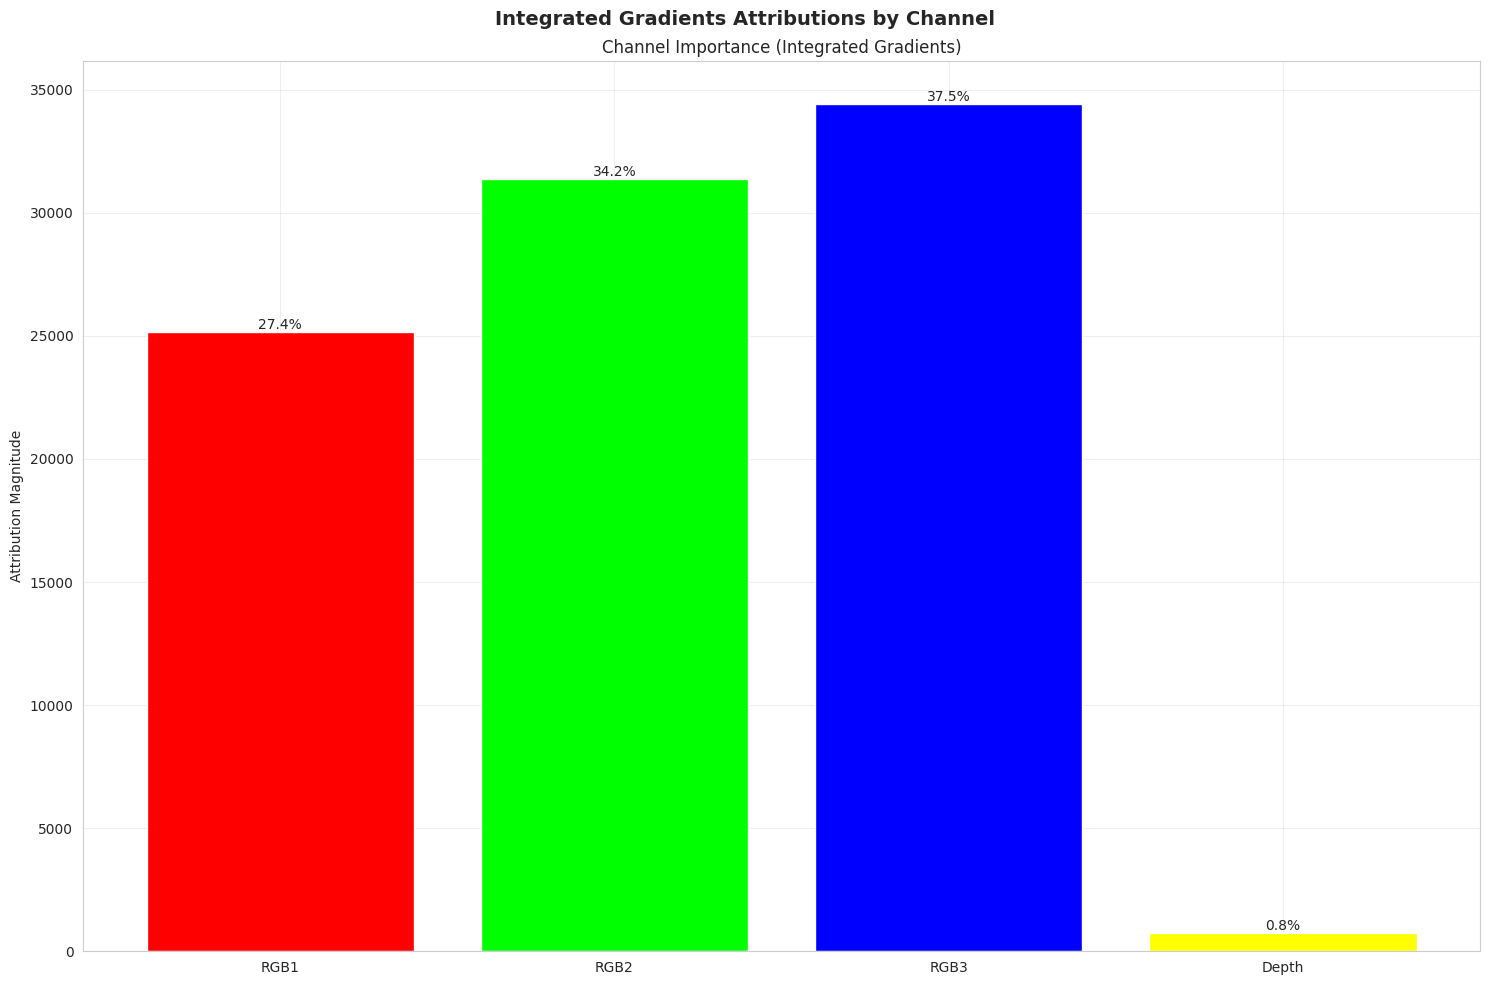

In [5]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import stable_worldmodel as swm
import stable_pretraining as spt
from preprocessing import rgbd_img_preprocessor


model = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)

dataset = swm.data.HDF5Dataset(**DATASET, transform=None)
transforms = [rgbd_img_preprocessor(img_size=IMG_SIZE)]
dataset.transform = spt.data.transforms.Compose(*transforms)

rnd_gen = torch.Generator().manual_seed(SEED)
train_loader = torch.utils.data.DataLoader(dataset, **LOADER, shuffle=True, drop_last=True, generator=rnd_gen)
batch = next(iter(train_loader))

results = analyze_model_channels(
    model=model,
    batch=batch,
    n_steps=30,
    visualize=True
)

# print(results)

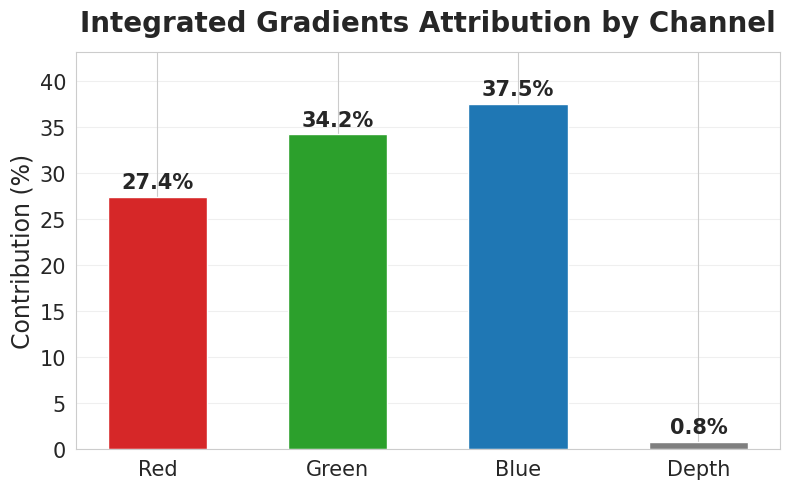

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

channel_names = ["Red", "Green", "Blue", "Depth"]

colors = [
    "#D62728",
    "#2CA02C",
    "#1F77B4",
    "#7F7F7F",   # gray for depth
]

importances = np.array([
    results["importance"].get("channel_0", 0),
    results["importance"].get("channel_1", 0),
    results["importance"].get("channel_2", 0),
    results["importance"].get("channel_3", 0),
])

percentages = 100 * importances / importances.sum()

bars = ax.bar(
    channel_names,
    percentages,
    color=colors,
    width=0.55,
)

# Labels
ax.set_title(
    "Integrated Gradients Attribution by Channel",
    fontsize=20,
    weight="bold",
    pad=15,
)

ax.set_ylabel("Contribution (%)", fontsize=17)

ax.set_ylim(0, max(percentages) * 1.15)

ax.tick_params(axis="both", labelsize=15)

# Only horizontal grid
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# Percentage labels
for bar, value in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=15,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(
    "integrated_gradients_channel_importance.pdf",
    bbox_inches="tight"   
)
plt.savefig(
    "integrated_gradients_channel_importance.png",
    bbox_inches="tight"   

)

In [14]:
plt.savefig(
    "integrated_gradients_channel_importance.pdf",
    bbox_inches="tight"   

)

<Figure size 640x480 with 0 Axes>